<a href="https://colab.research.google.com/github/weisses1/rawdata/blob/main/Capstone_2_Bringing_in_Forward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [367]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Forward Table

In [368]:
forward_15 = r'https://raw.githubusercontent.com/weisses1/rawdata/refs/heads/main/1516Forward.csv'
forward_15 = pd.read_csv(forward_15).dropna()

In [369]:
forward_16 = r'https://raw.githubusercontent.com/weisses1/rawdata/refs/heads/main/1617Forward.csv'
forward_16 = pd.read_csv(forward_16).dropna()

In [370]:
forward_17 = r'https://raw.githubusercontent.com/weisses1/rawdata/refs/heads/main/1718Forward.csv'
forward_17 = pd.read_csv(forward_17).dropna()

In [371]:
forward_18 = r'https://raw.githubusercontent.com/weisses1/rawdata/refs/heads/main/1819Forward.csv'
forward_18 = pd.read_csv(forward_18).dropna()

In [372]:
forward_20 = r'https://raw.githubusercontent.com/weisses1/rawdata/refs/heads/main/2021Forward.csv'
forward_20 = pd.read_csv(forward_20).dropna()

In [373]:
forward = pd.concat([forward_15, forward_16,forward_17,forward_18,forward_20], ignore_index=True).dropna()
forward.head(25)

,SCHOOL_YEAR,AGENCY_TYPE,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,CHARTER_IND,DISTRICT_NAME,SCHOOL_NAME,...,GRADE_LEVEL,TEST_RESULT,TEST_RESULT_CODE,TEST_GROUP,GROUP_BY,GROUP_BY_VALUE,STUDENT_COUNT,PERCENT_OF_GROUP,GROUP_COUNT,FORWARD_AVERAGE_SCALE_SCORE
0,2015-16,Public school,5,Adams,14,210,Middle School,No,Adams-Friendship Area,Adams-Friendship Middle,...,8,Below Basic,1,Forward,All Students,All Students,38,35.19,108,625.45
1,2015-16,Public school,5,Adams,14,210,Middle School,No,Adams-Friendship Area,Adams-Friendship Middle,...,8,Basic,2,Forward,All Students,All Students,32,29.63,108,625.45
2,2015-16,Public school,5,Adams,14,210,Middle School,No,Adams-Friendship Area,Adams-Friendship Middle,...,8,Proficient,3,Forward,All Students,All Students,26,24.07,108,625.45
3,2015-16,Public school,5,Adams,14,210,Middle School,No,Adams-Friendship Area,Adams-Friendship Middle,...,8,Advanced,4,Forward,All Students,All Students,10,9.26,108,625.45
4,2015-16,Public school,5,Adams,14,210,Middle School,No,Adams-Friendship Area,Adams-Friendship Middle,...,8,No Test,No Test,Forward,All Students,All Students,2,1.85,108,625.45
5,2015-16,Public school,5,Adams,14,210,Middle School,No,Adams-Friendship Area,Adams-Friendship Middle,...,8,Below Basic,1,Forward,Disability Status,SwD,11,64.71,17,569.19
6,2015-16,Public school,5,Adams,14,210,Middle School,No,Adams-Friendship Area,Adams-Friendship Middle,...,8,Basic,2,Forward,Disability Status,SwD,5,29.41,17,569.19
7,2015-16,Public school,5,Adams,14,210,Middle School,No,Adams-Friendship Area,Adams-Friendship Middle,...,8,No Test,No Test,Forward,Disability Status,SwD,1,5.88,17,569.19
8,2015-16,Public school,5,Adams,14,210,Middle School,No,Adams-Friendship Area,Adams-Friendship Middle,...,8,Below Basic,1,Forward,Disability Status,SwoD,27,29.67,91,635.46
9,2015-16,Public school,5,Adams,14,210,Middle School,No,Adams-Friendship Area,Adams-Friendship Middle,...,8,Basic,2,Forward,Disability Status,SwoD,27,29.67,91,635.46


In [374]:
forward = forward.drop(columns=['PERCENT_OF_GROUP','FORWARD_AVERAGE_SCALE_SCORE','TEST_GROUP','CHARTER_IND','GRADE_GROUP','AGENCY_TYPE'])
forward = forward.rename(columns={'GROUP_COUNT': 'COHORT_COUNT'})
forward

,SCHOOL_YEAR,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,DISTRICT_NAME,SCHOOL_NAME,TEST_SUBJECT,GRADE_LEVEL,TEST_RESULT,TEST_RESULT_CODE,GROUP_BY,GROUP_BY_VALUE,STUDENT_COUNT,COHORT_COUNT
0,2015-16,5,Adams,14,210,Adams-Friendship Area,Adams-Friendship Middle,ELA,8,Below Basic,1,All Students,All Students,38,108
1,2015-16,5,Adams,14,210,Adams-Friendship Area,Adams-Friendship Middle,ELA,8,Basic,2,All Students,All Students,32,108
2,2015-16,5,Adams,14,210,Adams-Friendship Area,Adams-Friendship Middle,ELA,8,Proficient,3,All Students,All Students,26,108
3,2015-16,5,Adams,14,210,Adams-Friendship Area,Adams-Friendship Middle,ELA,8,Advanced,4,All Students,All Students,10,108
4,2015-16,5,Adams,14,210,Adams-Friendship Area,Adams-Friendship Middle,ELA,8,No Test,No Test,All Students,All Students,2,108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374820,2020-21,7,Brown,6734,30,Wrightstown Community,Wrightstown Middle,Social Studies,8,*,*,Race/Ethnicity,Two or More,*,1
374821,2020-21,7,Brown,6734,30,Wrightstown Community,Wrightstown Middle,Social Studies,8,Below Basic,1,Race/Ethnicity,White,5,75
374822,2020-21,7,Brown,6734,30,Wrightstown Community,Wrightstown Middle,Social Studies,8,Basic,2,Race/Ethnicity,White,23,75
374823,2020-21,7,Brown,6734,30,Wrightstown Community,Wrightstown Middle,Social Studies,8,Proficient,3,Race/Ethnicity,White,27,75


In [457]:
forward['FORWARD_YEAR'] = forward['SCHOOL_YEAR'].str[:4].astype(int) +1
forward['COHORT'] = forward['FORWARD_YEAR'] + 4
forward

,SCHOOL_YEAR,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,DISTRICT_NAME,SCHOOL_NAME,TEST_SUBJECT,GRADE_LEVEL,TEST_RESULT,TEST_RESULT_CODE,GROUP_BY,GROUP_BY_VALUE,STUDENT_COUNT,COHORT_COUNT,FORWARD_YEAR,COHORT
0,2015-16,5,Adams,14,210,Adams-Friendship Area,Adams-Friendship Middle,ELA,8,Below Basic,1.0,All Students,All Students,38.0,108.0,2016,2020
1,2015-16,5,Adams,14,210,Adams-Friendship Area,Adams-Friendship Middle,ELA,8,Basic,2.0,All Students,All Students,32.0,108.0,2016,2020
2,2015-16,5,Adams,14,210,Adams-Friendship Area,Adams-Friendship Middle,ELA,8,Proficient,3.0,All Students,All Students,26.0,108.0,2016,2020
3,2015-16,5,Adams,14,210,Adams-Friendship Area,Adams-Friendship Middle,ELA,8,Advanced,4.0,All Students,All Students,10.0,108.0,2016,2020
4,2015-16,5,Adams,14,210,Adams-Friendship Area,Adams-Friendship Middle,ELA,8,No Test,NaN,All Students,All Students,2.0,108.0,2016,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374820,2020-21,7,Brown,6734,30,Wrightstown Community,Wrightstown Middle,Social Studies,8,*,NaN,Race/Ethnicity,Two or More,NaN,1.0,2021,2025
374821,2020-21,7,Brown,6734,30,Wrightstown Community,Wrightstown Middle,Social Studies,8,Below Basic,1.0,Race/Ethnicity,White,5.0,75.0,2021,2025
374822,2020-21,7,Brown,6734,30,Wrightstown Community,Wrightstown Middle,Social Studies,8,Basic,2.0,Race/Ethnicity,White,23.0,75.0,2021,2025
374823,2020-21,7,Brown,6734,30,Wrightstown Community,Wrightstown Middle,Social Studies,8,Proficient,3.0,Race/Ethnicity,White,27.0,75.0,2021,2025


In [458]:
forward['TEST_RESULT_CODE'] = pd.to_numeric(forward['TEST_RESULT_CODE'], errors='coerce')
forward['STUDENT_COUNT'] = pd.to_numeric(forward['STUDENT_COUNT'], errors='coerce')
forward['COHORT_COUNT'] = pd.to_numeric(forward['COHORT_COUNT'], errors='coerce')

forward = forward[~forward['GROUP_BY'].isin(['ELL Status', 'EL Status', 'Migrant Status'])].copy()

In [460]:
forward_subject_composite = (
    forward.groupby(['SCHOOL_YEAR','DISTRICT_NAME','COHORT','SCHOOL_NAME','GROUP_BY','GROUP_BY_VALUE', 'TEST_SUBJECT'])
    .apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum() / x['STUDENT_COUNT'].sum())
    .reset_index(name='composite_score'))
forward_subject_composite

/tmp/ipykernel_1987/949772761.py:3: RuntimeWarning: invalid value encountered in scalar divide
  .apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum() / x['STUDENT_COUNT'].sum())
/tmp/ipykernel_1987/949772761.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum() / x['STUDENT_COUNT'].sum())


,SCHOOL_YEAR,DISTRICT_NAME,COHORT,SCHOOL_NAME,GROUP_BY,GROUP_BY_VALUE,TEST_SUBJECT,composite_score
0,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,All Students,All Students,ELA,2.037037
1,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,All Students,All Students,Mathematics,1.879630
2,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,All Students,All Students,Science,2.250000
3,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,All Students,All Students,Social Studies,2.231481
4,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,Disability Status,SwD,ELA,1.235294
...,...,...,...,...,...,...,...,...
96409,2020-21,Wrightstown Community,2025,Wrightstown Middle,Race/Ethnicity,Two or More,Social Studies,NaN
96410,2020-21,Wrightstown Community,2025,Wrightstown Middle,Race/Ethnicity,White,ELA,2.586667
96411,2020-21,Wrightstown Community,2025,Wrightstown Middle,Race/Ethnicity,White,Mathematics,2.760000
96412,2020-21,Wrightstown Community,2025,Wrightstown Middle,Race/Ethnicity,White,Science,2.946667


In [461]:
forward_subject_composite_pivot = forward_subject_composite.pivot_table(
    index=['SCHOOL_YEAR','DISTRICT_NAME','COHORT','SCHOOL_NAME','GROUP_BY','GROUP_BY_VALUE'],
    columns='TEST_SUBJECT',
    values='composite_score'
).reset_index()
forward_subject_composite_pivot

TEST_SUBJECT,SCHOOL_YEAR,DISTRICT_NAME,COHORT,SCHOOL_NAME,GROUP_BY,GROUP_BY_VALUE,ELA,Mathematics,Science,Social Studies
0,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,All Students,All Students,2.037037,1.879630,2.250000,2.231481
1,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,Disability Status,SwD,1.235294,1.117647,1.470588,1.352941
2,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,Disability Status,SwoD,2.186813,2.021978,2.395604,2.395604
3,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,Economic Status,Econ Disadv,2.014085,1.845070,2.197183,2.197183
4,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,Economic Status,Not Econ Disadv,2.081081,1.945946,2.351351,2.297297
...,...,...,...,...,...,...,...,...,...,...
16079,2020-21,United Community Center Acosta Middle,2025,United Community Center Acosta Middle School,Economic Status,Econ Disadv,1.666667,1.527778,1.805556,1.666667
16080,2020-21,United Community Center Acosta Middle,2025,United Community Center Acosta Middle School,Economic Status,Not Econ Disadv,2.055556,1.500000,2.111111,1.888889
16081,2020-21,United Community Center Acosta Middle,2025,United Community Center Acosta Middle School,Gender,Female,1.846154,1.384615,1.923077,1.615385
16082,2020-21,United Community Center Acosta Middle,2025,United Community Center Acosta Middle School,Gender,Male,1.750000,1.642857,1.892857,1.857143


In [462]:
forward_composite = (
    forward.groupby(['SCHOOL_YEAR','DISTRICT_NAME','COHORT','SCHOOL_NAME','GROUP_BY','GROUP_BY_VALUE'])
    .apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum() / x['STUDENT_COUNT'].sum())
    .reset_index(name='composite_score'))
forward_composite

/tmp/ipykernel_1987/4173945078.py:3: RuntimeWarning: invalid value encountered in scalar divide
  .apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum() / x['STUDENT_COUNT'].sum())
/tmp/ipykernel_1987/4173945078.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum() / x['STUDENT_COUNT'].sum())


,SCHOOL_YEAR,DISTRICT_NAME,COHORT,SCHOOL_NAME,GROUP_BY,GROUP_BY_VALUE,composite_score
0,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,All Students,All Students,2.099537
1,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,Disability Status,SwD,1.294118
2,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,Disability Status,SwoD,2.250000
3,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,Economic Status,Econ Disadv,2.063380
4,2015-16,Adams-Friendship Area,2020,Adams-Friendship Middle,Economic Status,Not Econ Disadv,2.168919
...,...,...,...,...,...,...,...
24099,2020-21,Wrightstown Community,2025,Wrightstown Middle,Gender,Female,2.712121
24100,2020-21,Wrightstown Community,2025,Wrightstown Middle,Gender,Male,2.712264
24101,2020-21,Wrightstown Community,2025,Wrightstown Middle,Race/Ethnicity,Hispanic,NaN
24102,2020-21,Wrightstown Community,2025,Wrightstown Middle,Race/Ethnicity,Two or More,NaN


## Forward Table Info

In [378]:
forward.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302072 entries, 0 to 374824
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   SCHOOL_YEAR       302072 non-null  object 
 1   CESA              302072 non-null  int64  
 2   COUNTY            302072 non-null  object 
 3   DISTRICT_CODE     302072 non-null  int64  
 4   SCHOOL_CODE       302072 non-null  int64  
 5   DISTRICT_NAME     302072 non-null  object 
 6   SCHOOL_NAME       302072 non-null  object 
 7   TEST_SUBJECT      302072 non-null  object 
 8   GRADE_LEVEL       302072 non-null  int64  
 9   TEST_RESULT       302072 non-null  object 
 10  TEST_RESULT_CODE  236917 non-null  float64
 11  GROUP_BY          302072 non-null  object 
 12  GROUP_BY_VALUE    302072 non-null  object 
 13  STUDENT_COUNT     269912 non-null  float64
 14  COHORT_COUNT      295772 non-null  float64
dtypes: float64(3), int64(4), object(8)
memory usage: 36.9+ MB


In [379]:
forward.shape

(302072, 15)

In [380]:
forward.duplicated().sum()

np.int64(36)

In [381]:
forward.nunique(dropna=False)

,0
SCHOOL_YEAR,5
CESA,12
COUNTY,71
DISTRICT_CODE,326
SCHOOL_CODE,104
DISTRICT_NAME,327
SCHOOL_NAME,489
TEST_SUBJECT,4
GRADE_LEVEL,1
TEST_RESULT,6


In [382]:
forward.describe()

,CESA,DISTRICT_CODE,SCHOOL_CODE,GRADE_LEVEL,TEST_RESULT_CODE,STUDENT_COUNT,COHORT_COUNT
count,302072.000000,302072.000000,302072.000000,302072.0,236917.000000,269912.000000,295772.000000
mean,5.083159,3342.724576,222.792020,8.0,2.422059,17.657448,74.919418
std,3.460551,1843.744803,704.971333,0.0,1.092827,22.008697,75.574964
min,1.000000,14.000000,6.000000,8.0,1.000000,1.000000,1.000000
25%,2.000000,1900.000000,60.000000,8.0,1.000000,3.000000,19.000000
50%,5.000000,3332.000000,110.000000,8.0,2.000000,9.000000,50.000000
75%,7.000000,4641.000000,210.000000,8.0,3.000000,23.000000,107.000000
max,12.000000,8146.000000,9803.000000,8.0,4.000000,232.000000,606.000000


##Creating Composite Scores of Each Subject

La Crosse

In [383]:
forward['STUDENT_COUNT'] = pd.to_numeric(forward['STUDENT_COUNT'], errors='coerce')
forward['TEST_RESULT_CODE'] = pd.to_numeric(forward['TEST_RESULT_CODE'], errors='coerce')

In [384]:
def composite_by_district(forward, district_name,school_year):

    district = forward[(forward['DISTRICT_NAME'] == district_name) &(forward['SCHOOL_YEAR'] == school_year) &(forward['TEST_RESULT_CODE'].notna())]

    result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))
    result = result.reset_index()
    result = result.rename(columns={0: 'Composite_Score'})

    return result

In [385]:
lax_composite16 = composite_by_district(forward, 'La Crosse','2015-16')
lax_composite16

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.141657
1,Mathematics,2.028555
2,Science,2.442329
3,Social Studies,2.624232


In [386]:
lax_composite17 = composite_by_district(forward, 'La Crosse','2016-17')
lax_composite17

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.190642
1,Mathematics,2.045296
2,Science,2.357889
3,Social Studies,2.434717


In [387]:
lax_composite18 = composite_by_district(forward, 'La Crosse','2017-18')
lax_composite18

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.054745
1,Mathematics,2.064297
2,Science,2.395714
3,Social Studies,2.469760


In [388]:
lax_composite19 = composite_by_district(forward, 'La Crosse','2018-19')
lax_composite19

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.206299
1,Mathematics,2.015666
2,Science,2.500261
3,Social Studies,2.448294


In [389]:
lax_composite21 = composite_by_district(forward, 'La Crosse','2020-21')
lax_composite21

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.104712
1,Mathematics,1.902604
2,Science,2.461619
3,Social Studies,2.366771


In [390]:
lax_all_composite = pd.DataFrame({
    'SCHOOL_YEAR': ['2015-16','2016-17','2017-18','2018-19','2020-21'],
    'AVG_COMPOSITE': [lax_composite16['Composite_Score'].mean(),lax_composite17['Composite_Score'].mean(),lax_composite18['Composite_Score'].mean(),lax_composite19['Composite_Score'].mean(),lax_composite21['Composite_Score'].mean()]})
lax_all_composite

,SCHOOL_YEAR,AVG_COMPOSITE
0,2015-16,2.309194
1,2016-17,2.257136
2,2017-18,2.246129
3,2018-19,2.292630
4,2020-21,2.208927


GET

In [391]:
get_composite16 = composite_by_district(forward, 'Galesville-Ettrick-Trempealeau','2015-16')
get_composite16

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.454545
1,Mathematics,2.295455
2,Science,2.875000
3,Social Studies,2.886364


In [392]:
get_composite17 = composite_by_district(forward, 'Galesville-Ettrick-Trempealeau','2016-17')
get_composite17

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.163904
1,Mathematics,2.108656
2,Science,2.377532
3,Social Studies,2.451197


In [393]:
get_composite18 = composite_by_district(forward, 'Galesville-Ettrick-Trempealeau','2017-18')
get_composite18

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.323810
1,Mathematics,2.409524
2,Science,2.533333
3,Social Studies,2.819048


In [394]:
get_composite19 = composite_by_district(forward, 'Galesville-Ettrick-Trempealeau','2018-19')
get_composite19

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.205882
1,Mathematics,2.372549
2,Science,2.666667
3,Social Studies,2.745098


In [395]:
get_composite21 = composite_by_district(forward, 'Galesville-Ettrick-Trempealeau','2020-21')
get_composite21

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.540041
1,Mathematics,2.338809
2,Science,3.034908
3,Social Studies,2.872690


In [396]:
get_all_composite = pd.DataFrame({
    'SCHOOL_YEAR': ['2015-16','2016-17','2017-18','2018-19','2020-21'],
    'AVG_COMPOSITE': [get_composite16['Composite_Score'].mean(),get_composite17['Composite_Score'].mean(),get_composite18['Composite_Score'].mean(),get_composite19['Composite_Score'].mean(),get_composite21['Composite_Score'].mean()]})
get_all_composite

,SCHOOL_YEAR,AVG_COMPOSITE
0,2015-16,2.627841
1,2016-17,2.275322
2,2017-18,2.521429
3,2018-19,2.497549
4,2020-21,2.696612


Madison

In [397]:
mad_composite16 = composite_by_district(forward, 'Madison Metropolitan','2015-16')
mad_composite16

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.090897
1,Mathematics,2.041843
2,Science,2.288303
3,Social Studies,2.338380


In [398]:
mad_composite17 = composite_by_district(forward, 'Madison Metropolitan','2016-17')
mad_composite17

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.124403
1,Mathematics,2.057527
2,Science,2.318362
3,Social Studies,2.385541


In [399]:
mad_composite18 = composite_by_district(forward, 'Madison Metropolitan','2017-18')
mad_composite18

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.109865
1,Mathematics,2.072820
2,Science,2.366076
3,Social Studies,2.440616


In [400]:
mad_composite19 = composite_by_district(forward, 'Madison Metropolitan','2018-19')
mad_composite19

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.048601
1,Mathematics,2.035933
2,Science,2.372687
3,Social Studies,2.311969


In [401]:
mad_composite21 = composite_by_district(forward, 'Madison Metropolitan','2020-21')
mad_composite21

/tmp/ipykernel_1987/1882492350.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,1.980000
1,Mathematics,1.795631
2,Science,2.221484
3,Social Studies,2.206907


In [402]:
mad_all_composite = pd.DataFrame({
    'SCHOOL_YEAR': ['2015-16','2016-17','2017-18','2018-19','2020-21'],
    'AVG_COMPOSITE': [mad_composite16['Composite_Score'].mean(),mad_composite17['Composite_Score'].mean(),mad_composite18['Composite_Score'].mean(),mad_composite19['Composite_Score'].mean(),mad_composite21['Composite_Score'].mean()]})
mad_all_composite

,SCHOOL_YEAR,AVG_COMPOSITE
0,2015-16,2.189856
1,2016-17,2.221458
2,2017-18,2.247344
3,2018-19,2.192297
4,2020-21,2.051005


In [403]:
lax_all_composite['DISTRICT'] = 'La Crosse'

get_all_composite['DISTRICT'] = 'Galesville-Ettrick-Trempealeau'

mad_all_composite['DISTRICT'] = 'Madison Metropolitan'

In [404]:
all_composite = pd.concat([lax_all_composite,get_all_composite,mad_all_composite])
all_composite

,SCHOOL_YEAR,AVG_COMPOSITE,DISTRICT
0,2015-16,2.309194,La Crosse
1,2016-17,2.257136,La Crosse
2,2017-18,2.246129,La Crosse
3,2018-19,2.292630,La Crosse
4,2020-21,2.208927,La Crosse
0,2015-16,2.627841,Galesville-Ettrick-Trempealeau
1,2016-17,2.275322,Galesville-Ettrick-Trempealeau
2,2017-18,2.521429,Galesville-Ettrick-Trempealeau
3,2018-19,2.497549,Galesville-Ettrick-Trempealeau
4,2020-21,2.696612,Galesville-Ettrick-Trempealeau


All Years Combined

In [405]:
def composite_by_district_all_years(forward, district_name):
    district = forward[(forward['DISTRICT_NAME'] == district_name) &(forward['TEST_RESULT_CODE'].notna())]

    result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))

    result = result.reset_index()
    result = result.rename(columns={0: 'Composite_Score'})

    return result

In [406]:
composite_by_district_all_years(forward, 'La Crosse')

/tmp/ipykernel_1987/4183539494.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.140008
1,Mathematics,2.011317
2,Science,2.430698
3,Social Studies,2.466464


In [407]:
composite_by_district_all_years(forward, 'Galesville-Ettrick-Trempealeau')

/tmp/ipykernel_1987/4183539494.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.330886
1,Mathematics,2.300216
2,Science,2.677754
3,Social Studies,2.741253


In [408]:
composite_by_district_all_years(forward, 'Madison Metropolitan')

/tmp/ipykernel_1987/4183539494.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby('TEST_SUBJECT').apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,Composite_Score
0,ELA,2.081666
1,Mathematics,2.026299
2,Science,2.325539
3,Social Studies,2.353509


By Subgroups

In [409]:
def composite_by_district_subgroups(forward, district_name, school_year=None):
    keep_groups = ['All Students','Gender','Economic Status','Disability Status','Race/Ethnicity']
    district = forward[(forward['DISTRICT_NAME'] == district_name) &(forward['TEST_RESULT_CODE'].notna())]

    if school_year is not None:
        district = district[district['SCHOOL_YEAR'] == school_year]
    district = district[district['GROUP_BY'].isin(keep_groups)]

    result = (district.groupby(['TEST_SUBJECT', 'GROUP_BY', 'GROUP_BY_VALUE']).apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))

    result = result.reset_index()
    result = result.rename(columns={0: 'Composite_Score'})

    return result

In [410]:
composite_by_district_subgroups(forward,'La Crosse')

/tmp/ipykernel_1987/3087778911.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby(['TEST_SUBJECT', 'GROUP_BY', 'GROUP_BY_VALUE']).apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,GROUP_BY,GROUP_BY_VALUE,Composite_Score
0,ELA,All Students,All Students,2.139839
1,ELA,Disability Status,SwD,1.468880
2,ELA,Disability Status,SwoD,2.232317
3,ELA,Economic Status,Econ Disadv,1.836712
4,ELA,Economic Status,Not Econ Disadv,2.387582
5,ELA,Gender,Female,2.261424
6,ELA,Gender,Male,2.021825
7,ELA,Race/Ethnicity,Asian,2.031250
8,ELA,Race/Ethnicity,Black,1.448980
9,ELA,Race/Ethnicity,Hispanic,1.785714


In [411]:
composite_by_district_subgroups(forward,'Galesville-Ettrick-Trempealeau')

/tmp/ipykernel_1987/3087778911.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby(['TEST_SUBJECT', 'GROUP_BY', 'GROUP_BY_VALUE']).apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,GROUP_BY,GROUP_BY_VALUE,Composite_Score
0,ELA,All Students,All Students,2.331349
1,ELA,Disability Status,SwD,1.603175
2,ELA,Disability Status,SwoD,2.435374
3,ELA,Economic Status,Econ Disadv,2.145299
4,ELA,Economic Status,Not Econ Disadv,2.387597
5,ELA,Gender,Female,2.504098
6,ELA,Gender,Male,2.169231
7,ELA,Race/Ethnicity,Two or More,2.000000
8,ELA,Race/Ethnicity,White,2.334471
9,Mathematics,All Students,All Students,2.301587


In [412]:
composite_by_district_subgroups(forward,'Madison Metropolitan')

/tmp/ipykernel_1987/3087778911.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (district.groupby(['TEST_SUBJECT', 'GROUP_BY', 'GROUP_BY_VALUE']).apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,TEST_SUBJECT,GROUP_BY,GROUP_BY_VALUE,Composite_Score
0,ELA,All Students,All Students,2.080074
1,ELA,Disability Status,SwD,1.372508
2,ELA,Disability Status,SwoD,2.193467
3,ELA,Economic Status,Econ Disadv,1.568298
4,ELA,Economic Status,Not Econ Disadv,2.550110
5,ELA,Gender,Female,2.211289
6,ELA,Gender,Male,1.960876
7,ELA,Race/Ethnicity,Asian,2.338462
8,ELA,Race/Ethnicity,Black,1.394552
9,ELA,Race/Ethnicity,Hispanic,1.675623


In [413]:
districts = ['La Crosse','Galesville-Ettrick-Trempealeau','Madison Metropolitan']

In [414]:
def forward_subgroup_composites(forward, districts):
    keep_groups = ['All Students','Gender','Economic Status','Disability Status','Race/Ethnicity']

    subset = forward[(forward['DISTRICT_NAME'].isin(districts)) &(forward['TEST_RESULT_CODE'].notna()) &(forward['GROUP_BY'].isin(keep_groups))]

    result = (subset.groupby(['DISTRICT_NAME', 'SCHOOL_NAME','SCHOOL_YEAR','CESA','TEST_SUBJECT', 'GROUP_BY', 'GROUP_BY_VALUE']).apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))

    result = result.reset_index()
    result = result.rename(columns={0: 'Composite_Score'})

    return result

In [415]:
forward_subgroups = forward_subgroup_composites(forward, districts)
forward_subgroups.head()

/tmp/ipykernel_1987/4030100870.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = (subset.groupby(['DISTRICT_NAME', 'SCHOOL_NAME','SCHOOL_YEAR','CESA','TEST_SUBJECT', 'GROUP_BY', 'GROUP_BY_VALUE']).apply(lambda x: (x['TEST_RESULT_CODE'] * x['STUDENT_COUNT']).sum()/ x['STUDENT_COUNT'].sum()))


,DISTRICT_NAME,SCHOOL_NAME,SCHOOL_YEAR,CESA,TEST_SUBJECT,GROUP_BY,GROUP_BY_VALUE,Composite_Score
0,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau Middle,2015-16,4,ELA,All Students,All Students,2.454545
1,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau Middle,2015-16,4,ELA,Disability Status,SwD,1.636364
2,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau Middle,2015-16,4,ELA,Disability Status,SwoD,2.571429
3,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau Middle,2015-16,4,ELA,Economic Status,Econ Disadv,2.409091
4,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau Middle,2015-16,4,ELA,Economic Status,Not Econ Disadv,2.469697


##Merging together Datasets

In [416]:
grad_data = r'https://raw.githubusercontent.com/weisses1/rawdata/refs/heads/main/graduates.csv'
grad_data = pd.read_csv(grad_data).dropna()
grad_data
graduates_clean = grad_data[grad_data['COHORT_COUNT'] >= 25]

In [417]:
grad_subsets = graduates_clean[graduates_clean['DISTRICT_NAME'].isin(districts)]

#Pull Same Year Cohorts

In [418]:
forward_subgroups['FORWARD_YEAR'] = forward_subgroups['SCHOOL_YEAR'].str[:4].astype(int) +1
forward_subgroups['EXPECTED_COHORT'] = forward_subgroups['FORWARD_YEAR'] + 4
forward_subgroups

,DISTRICT_NAME,SCHOOL_NAME,SCHOOL_YEAR,CESA,TEST_SUBJECT,GROUP_BY,GROUP_BY_VALUE,Composite_Score,FORWARD_YEAR,EXPECTED_COHORT
0,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau Middle,2015-16,4,ELA,All Students,All Students,2.454545,2016,2020
1,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau Middle,2015-16,4,ELA,Disability Status,SwD,1.636364,2016,2020
2,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau Middle,2015-16,4,ELA,Disability Status,SwoD,2.571429,2016,2020
3,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau Middle,2015-16,4,ELA,Economic Status,Econ Disadv,2.409091,2016,2020
4,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau Middle,2015-16,4,ELA,Economic Status,Not Econ Disadv,2.469697,2016,2020
...,...,...,...,...,...,...,...,...,...,...
3482,Madison Metropolitan,Whitehorse Middle,2020-21,2,Social Studies,Race/Ethnicity,Asian,1.000000,2021,2025
3483,Madison Metropolitan,Whitehorse Middle,2020-21,2,Social Studies,Race/Ethnicity,Black,1.181818,2021,2025
3484,Madison Metropolitan,Whitehorse Middle,2020-21,2,Social Studies,Race/Ethnicity,Hispanic,1.315789,2021,2025
3485,Madison Metropolitan,Whitehorse Middle,2020-21,2,Social Studies,Race/Ethnicity,Two or More,2.100000,2021,2025


In [419]:
graduates_clean.loc[:, 'SCHOOL_NAME'] = (graduates_clean['SCHOOL_NAME'].replace({'Vel Phillips Memorial High School': 'Memorial High','Innovative & Alternative High': 'Innovative High'}))

In [420]:
grad_2020 = graduates_clean[(graduates_clean['COHORT'] == 2020) &(graduates_clean['DISTRICT_NAME'].isin(districts)&(graduates_clean['COMPLETION_STATUS'] == 'Completed - Regular High School Diploma') &(graduates_clean['TIMEFRAME'] == '4-Year rate'))]
grad_2020

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT
14857,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,103,96
14863,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Disability Status,SwoD,4-Year rate,94,90
14870,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,79,76
14873,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,EL Status,Eng Prof,4-Year rate,103,96
14876,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Gender,Female,4-Year rate,49,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16976,2019-20,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2020,Completed - Regular High School Diploma,Migrant Status,Not Migrant,4-Year rate,555,503
16980,2019-20,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2020,Completed - Regular High School Diploma,Race/Ethnicity,Asian,4-Year rate,43,39
16982,2019-20,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2020,Completed - Regular High School Diploma,Race/Ethnicity,Black,4-Year rate,63,46
16985,2019-20,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2020,Completed - Regular High School Diploma,Race/Ethnicity,Hispanic,4-Year rate,124,107


In [421]:
graduates_clean[graduates_clean['DISTRICT_NAME'].isin(districts)].SCHOOL_NAME.value_counts()

,count
SCHOOL_NAME,
Memorial High,337
LaFollette High,325
East High,320
West High,310
Innovative High,225
Central High,201
Logan High,190
Galesville-Ettrick-Trempealeau High,125
Capital High,101


In [422]:
drop = ['Capital High','Shabazz-City High','Innovative High','LaCrossroads Charter']

graduates_clean = graduates_clean[~graduates_clean['SCHOOL_NAME'].isin(drop)]

In [423]:
grad_2021 = graduates_clean[(graduates_clean['COHORT'] == 2021) &(graduates_clean['DISTRICT_NAME'].isin(districts)&(graduates_clean['COMPLETION_STATUS'] == 'Completed - Regular High School Diploma') &(graduates_clean['TIMEFRAME'] == '4-Year rate'))]
grad_2021

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT
29372,2020-21,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2021,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,126,118
29378,2020-21,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2021,Completed - Regular High School Diploma,Disability Status,SwoD,4-Year rate,106,104
29382,2020-21,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2021,Completed - Regular High School Diploma,Economic Status,Econ Disadv,4-Year rate,33,28
29384,2020-21,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2021,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,93,90
29387,2020-21,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2021,Completed - Regular High School Diploma,Gender,Female,4-Year rate,61,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33167,2020-21,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2021,Completed - Regular High School Diploma,Migrant Status,Not Migrant,4-Year rate,509,461
33171,2020-21,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2021,Completed - Regular High School Diploma,Race/Ethnicity,Asian,4-Year rate,58,55
33174,2020-21,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2021,Completed - Regular High School Diploma,Race/Ethnicity,Black,4-Year rate,57,38
33178,2020-21,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2021,Completed - Regular High School Diploma,Race/Ethnicity,Hispanic,4-Year rate,75,58


In [424]:
grad_2022 = graduates_clean[(graduates_clean['COHORT'] == 2022) &(graduates_clean['DISTRICT_NAME'].isin(districts)&(graduates_clean['COMPLETION_STATUS'] == 'Completed - Regular High School Diploma') &(graduates_clean['TIMEFRAME'] == '4-Year rate'))]
grad_2022

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT
50217,2021-22,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2022,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,108,102
50222,2021-22,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2022,Completed - Regular High School Diploma,Disability Status,SwoD,4-Year rate,95,90
50226,2021-22,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2022,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,88,84
50229,2021-22,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2022,Completed - Regular High School Diploma,Gender,Female,4-Year rate,57,56
50231,2021-22,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2022,Completed - Regular High School Diploma,Gender,Male,4-Year rate,51,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53986,2021-22,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2022,Completed - Regular High School Diploma,Migrant Status,Not Migrant,4-Year rate,556,519
53989,2021-22,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2022,Completed - Regular High School Diploma,Race/Ethnicity,Black,4-Year rate,51,40
53992,2021-22,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2022,Completed - Regular High School Diploma,Race/Ethnicity,Hispanic,4-Year rate,105,92
53995,2021-22,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2022,Completed - Regular High School Diploma,Race/Ethnicity,Two or More,4-Year rate,58,55


In [425]:
grad_2023 = graduates_clean[(graduates_clean['COHORT'] == 2023) &(graduates_clean['DISTRICT_NAME'].isin(districts)&(graduates_clean['COMPLETION_STATUS'] == 'Completed - Regular High School Diploma') &(graduates_clean['TIMEFRAME'] == '4-Year rate'))]
grad_2023

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT
71237,2022-23,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2023,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,102,98
71241,2022-23,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2023,Completed - Regular High School Diploma,Disability Status,SwoD,4-Year rate,91,90
71245,2022-23,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2023,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,82,80
71247,2022-23,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2023,Completed - Regular High School Diploma,EL Status,Eng Prof,4-Year rate,102,98
71249,2022-23,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2023,Completed - Regular High School Diploma,Gender,Female,4-Year rate,49,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74940,2022-23,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2023,Completed - Regular High School Diploma,Migrant Status,Not Migrant,4-Year rate,522,461
74943,2022-23,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2023,Completed - Regular High School Diploma,Race/Ethnicity,Asian,4-Year rate,52,46
74946,2022-23,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2023,Completed - Regular High School Diploma,Race/Ethnicity,Black,4-Year rate,54,36
74949,2022-23,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2023,Completed - Regular High School Diploma,Race/Ethnicity,Hispanic,4-Year rate,121,93


In [426]:
grad_2025 = graduates_clean[(graduates_clean['COHORT'] == 2025) &(graduates_clean['DISTRICT_NAME'].isin(districts)&(graduates_clean['COMPLETION_STATUS'] == 'Completed - Regular High School Diploma') &(graduates_clean['TIMEFRAME'] == '4-Year rate'))]
grad_2025

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT
112746,2024-25,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2025,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,109,108
112750,2024-25,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2025,Completed - Regular High School Diploma,Disability Status,SwoD,4-Year rate,94,94
112751,2024-25,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2025,Completed - Regular High School Diploma,Economic Status,Econ Disadv,4-Year rate,26,25
112753,2024-25,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2025,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,83,83
112754,2024-25,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2025,Completed - Regular High School Diploma,Gender,Female,4-Year rate,47,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116410,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Migrant Status,Not Migrant,4-Year rate,534,476
116413,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Asian,4-Year rate,52,50
116415,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Black,4-Year rate,41,34
116417,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Hispanic,4-Year rate,119,88


In [427]:
graduates = pd.concat([grad_2020,grad_2021,grad_2022,grad_2023,grad_2025], ignore_index=True).dropna()
graduates

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT
0,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,103,96
1,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Disability Status,SwoD,4-Year rate,94,90
2,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,79,76
3,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,EL Status,Eng Prof,4-Year rate,103,96
4,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Gender,Female,4-Year rate,49,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Migrant Status,Not Migrant,4-Year rate,534,476
405,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Asian,4-Year rate,52,50
406,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Black,4-Year rate,41,34
407,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Hispanic,4-Year rate,119,88


In [428]:
graduates = graduates[~graduates['GROUP_BY'].isin(['Migrant Status', 'EL Status','ELL Status'])]
graduates

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT
0,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,103,96
1,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Disability Status,SwoD,4-Year rate,94,90
2,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,79,76
4,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Gender,Female,4-Year rate,49,49
5,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Gender,Male,4-Year rate,54,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Gender,Female,4-Year rate,275,254
405,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Asian,4-Year rate,52,50
406,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Black,4-Year rate,41,34
407,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Hispanic,4-Year rate,119,88


In [429]:
graduates

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT
0,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,103,96
1,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Disability Status,SwoD,4-Year rate,94,90
2,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,79,76
4,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Gender,Female,4-Year rate,49,49
5,2019-20,Public school,No,4.0,Trempealeau,2009,40.0,High School,Galesville-Ettrick-Trempealeau,Galesville-Ettrick-Trempealeau High,2020,Completed - Regular High School Diploma,Gender,Male,4-Year rate,54,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Gender,Female,4-Year rate,275,254
405,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Asian,4-Year rate,52,50
406,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Black,4-Year rate,41,34
407,2024-25,Public school,No,2.0,Dane,3269,840.0,High School,Madison Metropolitan,West High,2025,Completed - Regular High School Diploma,Race/Ethnicity,Hispanic,4-Year rate,119,88


In [430]:
grad_rate = (graduates.groupby(['DISTRICT_NAME', 'COHORT']).agg({'STUDENT_COUNT':'sum', 'COHORT_COUNT':'sum'}).reset_index())
grad_rate['GRAD_RATE'] = grad_rate['STUDENT_COUNT'] / grad_rate['COHORT_COUNT']

In [431]:
grad_rate

,DISTRICT_NAME,COHORT,STUDENT_COUNT,COHORT_COUNT,GRAD_RATE
0,Galesville-Ettrick-Trempealeau,2020,358,379,0.944591
1,Galesville-Ettrick-Trempealeau,2021,566,599,0.944908
2,Galesville-Ettrick-Trempealeau,2022,378,399,0.947368
3,Galesville-Ettrick-Trempealeau,2023,458,473,0.968288
4,Galesville-Ettrick-Trempealeau,2025,515,519,0.992293
5,La Crosse,2020,1686,1854,0.909385
6,La Crosse,2021,2059,2351,0.875798
7,La Crosse,2022,1883,2058,0.914966
8,La Crosse,2023,1904,2088,0.911877
9,La Crosse,2025,1919,1988,0.965292


#Merge Datasets

Overall

In [432]:
graduates.shape

(331, 17)

In [433]:
forward_subgroups.shape

(3487, 10)

In [467]:
forward_dist = forward_subgroups.groupby(['DISTRICT_NAME', 'CESA','GROUP_BY', 'GROUP_BY_VALUE', 'EXPECTED_COHORT', 'TEST_SUBJECT'])['Composite_Score'].mean().reset_index()

grad_dist = graduates.groupby(['DISTRICT_NAME','GROUP_BY', 'GROUP_BY_VALUE', 'COHORT'])[['STUDENT_COUNT', 'COHORT_COUNT']].sum().reset_index()

merged = grad_dist.merge(forward_dist,left_on=['DISTRICT_NAME', 'GROUP_BY', 'GROUP_BY_VALUE', 'COHORT'],right_on=['DISTRICT_NAME', 'GROUP_BY', 'GROUP_BY_VALUE', 'EXPECTED_COHORT'],how='left')

merged['GRAD_RATE'] = (merged['STUDENT_COUNT'] / merged['COHORT_COUNT'])

In [468]:
merged = merged.drop(columns=['EXPECTED_COHORT'])

In [469]:
merged

,DISTRICT_NAME,GROUP_BY,GROUP_BY_VALUE,COHORT,STUDENT_COUNT,COHORT_COUNT,CESA,TEST_SUBJECT,Composite_Score,GRAD_RATE
0,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,ELA,2.454545,0.932039
1,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,Mathematics,2.295455,0.932039
2,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,Science,2.875000,0.932039
3,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,Social Studies,2.886364,0.932039
4,Galesville-Ettrick-Trempealeau,All Students,All Students,2021,118,126,4.0,ELA,2.172727,0.936508
...,...,...,...,...,...,...,...,...,...,...
520,Madison Metropolitan,Race/Ethnicity,White,2023,717,755,2.0,Social Studies,2.901382,0.949669
521,Madison Metropolitan,Race/Ethnicity,White,2025,718,759,2.0,ELA,2.357189,0.945982
522,Madison Metropolitan,Race/Ethnicity,White,2025,718,759,2.0,Mathematics,2.093873,0.945982
523,Madison Metropolitan,Race/Ethnicity,White,2025,718,759,2.0,Science,2.672298,0.945982


In [470]:
merged.to_csv('composite_merged.csv',index=False)

In [471]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DISTRICT_NAME    525 non-null    object 
 1   GROUP_BY         525 non-null    object 
 2   GROUP_BY_VALUE   525 non-null    object 
 3   COHORT           525 non-null    int64  
 4   STUDENT_COUNT    525 non-null    int64  
 5   COHORT_COUNT     525 non-null    int64  
 6   CESA             524 non-null    float64
 7   TEST_SUBJECT     524 non-null    object 
 8   Composite_Score  524 non-null    float64
 9   GRAD_RATE        525 non-null    float64
dtypes: float64(3), int64(3), object(4)
memory usage: 41.1+ KB


<Axes: xlabel='GRAD_RATE', ylabel='Composite_Score'>

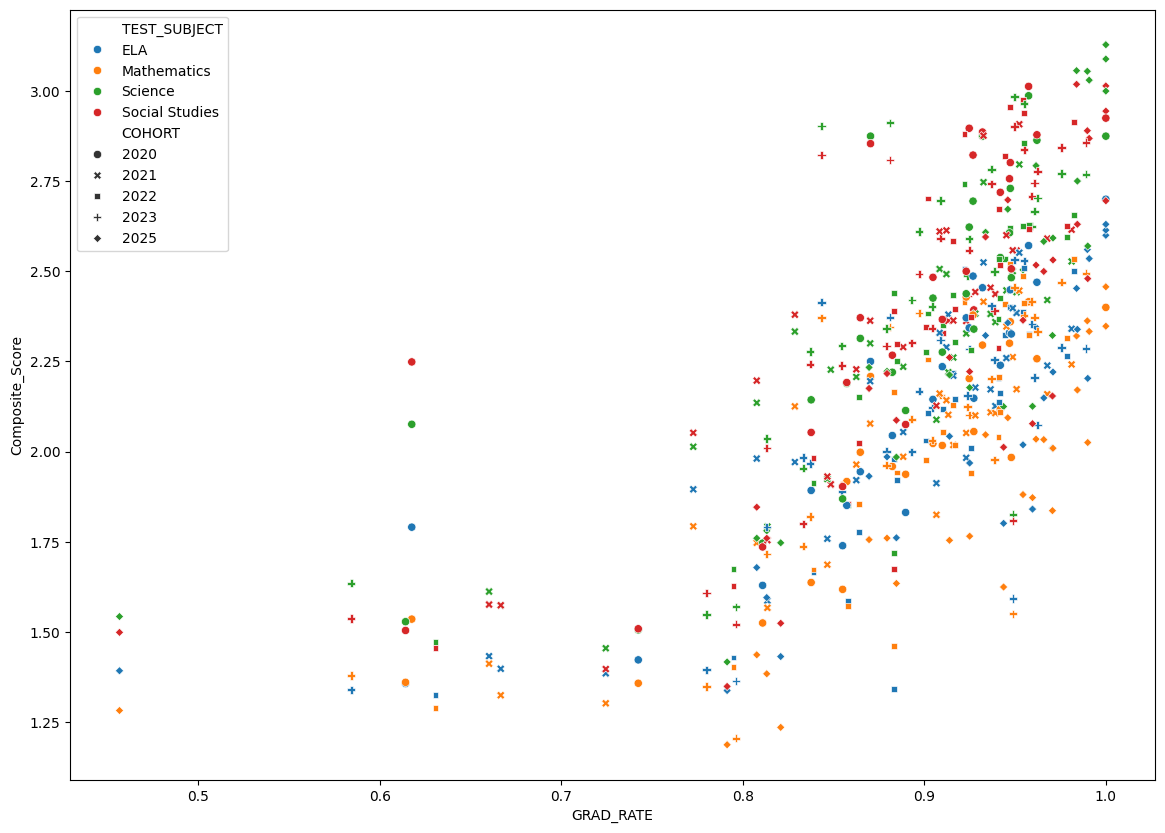

In [472]:
fig, axes = plt.subplots(figsize=(14, 10))
sns.scatterplot(data=merged, x='GRAD_RATE', y='Composite_Score',hue='TEST_SUBJECT',style='COHORT')

In [439]:
pivot_subjects = merged.pivot_table(index=['CESA', 'DISTRICT_NAME', 'GROUP_BY', 'GROUP_BY_VALUE', 'COHORT','GRAD_RATE'],columns='TEST_SUBJECT',values='Composite_Score',aggfunc='mean').reset_index()
pivot_subjects

TEST_SUBJECT,CESA,DISTRICT_NAME,GROUP_BY,GROUP_BY_VALUE,COHORT,GRAD_RATE,ELA,Mathematics,Science,Social Studies
0,2.0,Madison Metropolitan,All Students,All Students,2020,0.882385,2.044550,1.958831,2.220059,2.267299
1,2.0,Madison Metropolitan,All Students,All Students,2021,0.888380,2.054209,1.985684,2.235250,2.289889
2,2.0,Madison Metropolitan,All Students,All Students,2022,0.900876,2.030783,1.977034,2.275367,2.345564
3,2.0,Madison Metropolitan,All Students,All Students,2023,0.879133,2.000792,1.961900,2.341079,2.292620
4,2.0,Madison Metropolitan,All Students,All Students,2025,0.879444,1.985319,1.759985,2.222706,2.216470
...,...,...,...,...,...,...,...,...,...,...
126,4.0,La Crosse,Race/Ethnicity,White,2020,0.924731,2.343268,2.202673,2.622712,2.896846
127,4.0,La Crosse,Race/Ethnicity,White,2021,0.912181,2.289476,2.142511,2.492333,2.613483
128,4.0,La Crosse,Race/Ethnicity,White,2022,0.940994,2.138202,2.206792,2.533639,2.673852
129,4.0,La Crosse,Race/Ethnicity,White,2023,0.937086,2.404658,2.202220,2.783539,2.742680


<Axes: xlabel='GRAD_RATE', ylabel='ELA'>

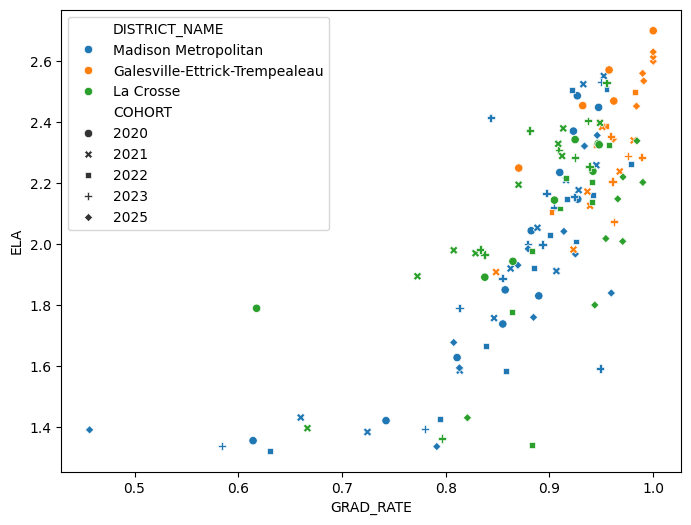

In [440]:
fig, axes = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=pivot_subjects, x='GRAD_RATE', y='ELA',hue='DISTRICT_NAME',style='COHORT')

<Axes: xlabel='GRAD_RATE', ylabel='Mathematics'>

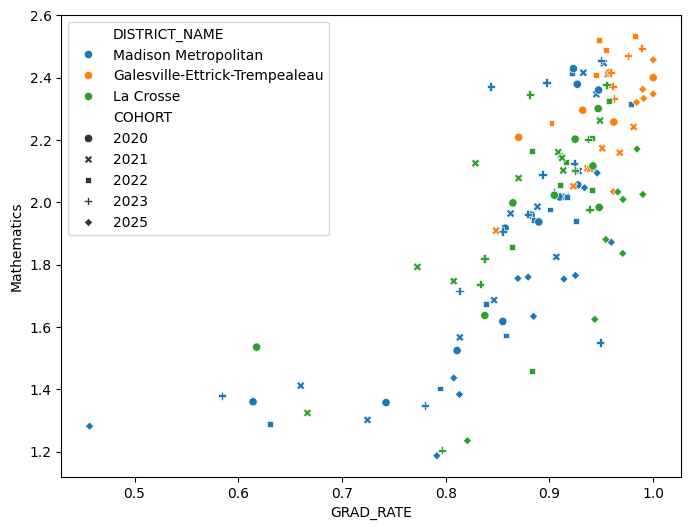

In [441]:
fig, axes = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=pivot_subjects, x='GRAD_RATE', y='Mathematics',hue='DISTRICT_NAME',style='COHORT')

<Axes: xlabel='GRAD_RATE', ylabel='Science'>

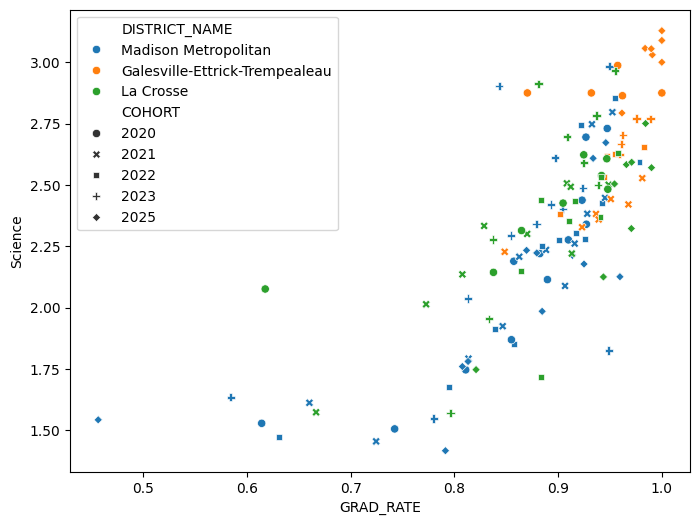

In [442]:
fig, axes = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=pivot_subjects, x='GRAD_RATE', y='Science',hue='DISTRICT_NAME',style='COHORT')

<Axes: xlabel='GRAD_RATE', ylabel='Social Studies'>

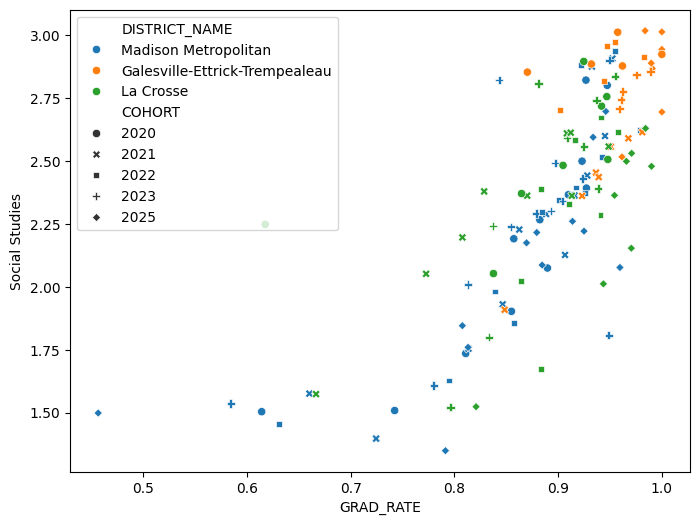

In [443]:
fig, axes = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=pivot_subjects, x='GRAD_RATE', y='Social Studies',hue='DISTRICT_NAME',style='COHORT')

In [444]:
all_composite

,SCHOOL_YEAR,AVG_COMPOSITE,DISTRICT
0,2015-16,2.309194,La Crosse
1,2016-17,2.257136,La Crosse
2,2017-18,2.246129,La Crosse
3,2018-19,2.292630,La Crosse
4,2020-21,2.208927,La Crosse
0,2015-16,2.627841,Galesville-Ettrick-Trempealeau
1,2016-17,2.275322,Galesville-Ettrick-Trempealeau
2,2017-18,2.521429,Galesville-Ettrick-Trempealeau
3,2018-19,2.497549,Galesville-Ettrick-Trempealeau
4,2020-21,2.696612,Galesville-Ettrick-Trempealeau


In [445]:
grad_rate

,DISTRICT_NAME,COHORT,STUDENT_COUNT,COHORT_COUNT,GRAD_RATE
0,Galesville-Ettrick-Trempealeau,2020,358,379,0.944591
1,Galesville-Ettrick-Trempealeau,2021,566,599,0.944908
2,Galesville-Ettrick-Trempealeau,2022,378,399,0.947368
3,Galesville-Ettrick-Trempealeau,2023,458,473,0.968288
4,Galesville-Ettrick-Trempealeau,2025,515,519,0.992293
5,La Crosse,2020,1686,1854,0.909385
6,La Crosse,2021,2059,2351,0.875798
7,La Crosse,2022,1883,2058,0.914966
8,La Crosse,2023,1904,2088,0.911877
9,La Crosse,2025,1919,1988,0.965292


In [446]:
year_to_cohort = {'2015-16': 2020,'2016-17': 2021,'2017-18': 2022,'2018-19': 2023,'2020-21': 2025}

all_composite['COHORT'] = all_composite['SCHOOL_YEAR'].map(year_to_cohort)

In [447]:
grad_rate

,DISTRICT_NAME,COHORT,STUDENT_COUNT,COHORT_COUNT,GRAD_RATE
0,Galesville-Ettrick-Trempealeau,2020,358,379,0.944591
1,Galesville-Ettrick-Trempealeau,2021,566,599,0.944908
2,Galesville-Ettrick-Trempealeau,2022,378,399,0.947368
3,Galesville-Ettrick-Trempealeau,2023,458,473,0.968288
4,Galesville-Ettrick-Trempealeau,2025,515,519,0.992293
5,La Crosse,2020,1686,1854,0.909385
6,La Crosse,2021,2059,2351,0.875798
7,La Crosse,2022,1883,2058,0.914966
8,La Crosse,2023,1904,2088,0.911877
9,La Crosse,2025,1919,1988,0.965292


In [448]:
all_composite

,SCHOOL_YEAR,AVG_COMPOSITE,DISTRICT,COHORT
0,2015-16,2.309194,La Crosse,2020
1,2016-17,2.257136,La Crosse,2021
2,2017-18,2.246129,La Crosse,2022
3,2018-19,2.292630,La Crosse,2023
4,2020-21,2.208927,La Crosse,2025
0,2015-16,2.627841,Galesville-Ettrick-Trempealeau,2020
1,2016-17,2.275322,Galesville-Ettrick-Trempealeau,2021
2,2017-18,2.521429,Galesville-Ettrick-Trempealeau,2022
3,2018-19,2.497549,Galesville-Ettrick-Trempealeau,2023
4,2020-21,2.696612,Galesville-Ettrick-Trempealeau,2025


In [449]:
all_composite = all_composite.merge(grad_rate[['DISTRICT_NAME','COHORT','GRAD_RATE']],left_on=['DISTRICT','COHORT'],right_on=['DISTRICT_NAME','COHORT'],how='left').drop(columns=['DISTRICT_NAME'])
all_composite

,SCHOOL_YEAR,AVG_COMPOSITE,DISTRICT,COHORT,GRAD_RATE
0,2015-16,2.309194,La Crosse,2020,0.909385
1,2016-17,2.257136,La Crosse,2021,0.875798
2,2017-18,2.246129,La Crosse,2022,0.914966
3,2018-19,2.292630,La Crosse,2023,0.911877
4,2020-21,2.208927,La Crosse,2025,0.965292
5,2015-16,2.627841,Galesville-Ettrick-Trempealeau,2020,0.944591
6,2016-17,2.275322,Galesville-Ettrick-Trempealeau,2021,0.944908
7,2017-18,2.521429,Galesville-Ettrick-Trempealeau,2022,0.947368
8,2018-19,2.497549,Galesville-Ettrick-Trempealeau,2023,0.968288
9,2020-21,2.696612,Galesville-Ettrick-Trempealeau,2025,0.992293


<Axes: xlabel='GRAD_RATE', ylabel='AVG_COMPOSITE'>

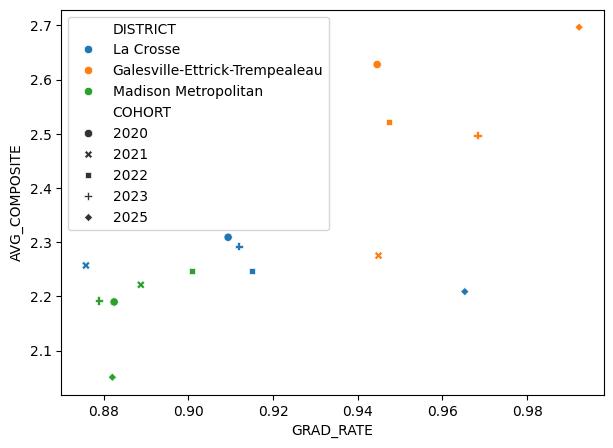

In [450]:
fig, axes = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=all_composite, x='GRAD_RATE', y='AVG_COMPOSITE',hue='DISTRICT',style='COHORT')

In [451]:
all_composite.to_csv('all_composite.csv',index=False)